## Supply Chain Analytics & Inventory Optimization
#### Demand Forecasting

**aim:**

develop a demand forecasting model to predict future daily demand for each SKU using historical sales data. These forecasts will serve as the foundation for inventory optimization and replenishment recommendations.

**business objective:**

inventory decisions should be based on expected future demand rather than historical sales alone. Accurate demand forecasting helps reduce excess inventory, minimize stockouts, and improve replenishment planning.

#

In [4]:
import pandas as pd
import numpy as np

In [5]:
df= pd.read_csv("data used/processed_supply_chain.csv")
print(df['date'].dtype)

object


In [6]:
forecast_df= df.groupby(['date','warehouse_id','sku_id']).agg({
    'units_sold':'sum',
    'inventory_level':'sum',
    'promotion_flag':'max',
    'supplier_lead_time_days':'mean',
    'reorder_point':'sum',
    'unit_price':'mean',
    'unit_cost':'mean',
    'stockout_flag':'max'}).reset_index()

In [7]:
#preparing time-series: forecasting daily units sold for each SKU
df['date'] = pd.to_datetime(df['date'])
forecast_df.head()

,date,warehouse_id,sku_id,units_sold,inventory_level,promotion_flag,supplier_lead_time_days,reorder_point,unit_price,unit_cost,stockout_flag
0,2024-01-01,WH_1,SKU_1,10,592,0,14.0,379,20.48,13.95,0
1,2024-01-01,WH_1,SKU_10,24,835,0,13.0,361,18.73,12.67,0
2,2024-01-01,WH_1,SKU_11,18,922,0,4.0,286,34.79,19.54,0
3,2024-01-01,WH_1,SKU_12,17,964,0,5.0,299,7.17,5.36,0
4,2024-01-01,WH_1,SKU_13,21,870,0,9.0,246,24.09,19.52,0


In [8]:
#encoding sku_id and warehouse_id
from sklearn.preprocessing import LabelEncoder
encoder= LabelEncoder()
forecast_df['sku_encoded']= encoder.fit_transform(forecast_df['sku_id'])
forecast_df['warehouse_encoded']= encoder.fit_transform(forecast_df['warehouse_id'])

In [9]:
#sorting dataset:
forecast_df = forecast_df.sort_values(['warehouse_id','sku_id','date']).reset_index(drop=True)

#### Feature engineering for time-series

In [10]:
#time based features:
forecast_df['date'] = pd.to_datetime(forecast_df['date'])
forecast_df['year']= forecast_df['date'].dt.year
forecast_df['month']= forecast_df['date'].dt.month
forecast_df['day_of_week']= forecast_df['date'].dt.dayofweek
forecast_df['is_weekend']= (forecast_df['day_of_week']>= 5).astype(int)

In [11]:
#lag features: (a day ago, a week ago, a month ago):

forecast_df['lag_1']= forecast_df.groupby(['warehouse_id', 'sku_id'])['units_sold'].shift(1)
forecast_df['lag_7']= forecast_df.groupby(['warehouse_id', 'sku_id'])['units_sold'].shift(7)
forecast_df['lag_30']= forecast_df.groupby(['warehouse_id', 'sku_id'])['units_sold'].shift(30)


In [12]:
#rolling-mean features: (weekly, monthly)

forecast_df['rolling_mean_7']= forecast_df.groupby(['warehouse_id', 'sku_id'])['units_sold'].transform(lambda x: x.shift(1).rolling(7).mean())
forecast_df['rolling_mean_30']= forecast_df.groupby(['warehouse_id', 'sku_id'])['units_sold'].transform(lambda x: x.shift(1).rolling(30).mean())

In [13]:
#rolling standard deviation:

forecast_df['rolling_std_7']= forecast_df.groupby(['warehouse_id', 'sku_id'])[['units_sold']].transform(lambda x: x.shift(1).rolling(7).std())

In [14]:
forecast_df.isnull().sum()

date                          0
warehouse_id                  0
sku_id                        0
units_sold                    0
inventory_level               0
promotion_flag                0
supplier_lead_time_days       0
reorder_point                 0
unit_price                    0
unit_cost                     0
stockout_flag                 0
sku_encoded                   0
warehouse_encoded             0
year                          0
month                         0
day_of_week                   0
is_weekend                    0
lag_1                       250
lag_7                      1750
lag_30                     7500
rolling_mean_7             1750
rolling_mean_30            7500
rolling_std_7              1750
dtype: int64

In [15]:
forecast_df[forecast_df['sku_id']=='SKU_1'].head(12)

,date,warehouse_id,sku_id,units_sold,inventory_level,promotion_flag,supplier_lead_time_days,reorder_point,unit_price,unit_cost,...,year,month,day_of_week,is_weekend,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7
0,2024-01-01,WH_1,SKU_1,10,592,0,14.0,379,20.48,13.95,...,2024,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-02,WH_1,SKU_1,17,575,0,14.0,379,20.48,13.95,...,2024,1,1,0,10.0,NaN,NaN,NaN,NaN,NaN
2,2024-01-03,WH_1,SKU_1,35,540,1,14.0,379,20.48,13.95,...,2024,1,2,0,17.0,NaN,NaN,NaN,NaN,NaN
3,2024-01-04,WH_1,SKU_1,24,516,0,14.0,379,20.48,13.95,...,2024,1,3,0,35.0,NaN,NaN,NaN,NaN,NaN
4,2024-01-05,WH_1,SKU_1,21,495,0,14.0,379,20.48,13.95,...,2024,1,4,0,24.0,NaN,NaN,NaN,NaN,NaN
5,2024-01-06,WH_1,SKU_1,18,477,0,14.0,379,20.48,13.95,...,2024,1,5,1,21.0,NaN,NaN,NaN,NaN,NaN
6,2024-01-07,WH_1,SKU_1,19,458,0,14.0,379,20.48,13.95,...,2024,1,6,1,18.0,NaN,NaN,NaN,NaN,NaN
7,2024-01-08,WH_1,SKU_1,23,435,1,14.0,379,20.48,13.95,...,2024,1,0,0,19.0,10.0,NaN,20.571429,NaN,7.678045
8,2024-01-09,WH_1,SKU_1,25,410,0,14.0,379,20.48,13.95,...,2024,1,1,0,23.0,17.0,NaN,22.428571,NaN,6.106203
9,2024-01-10,WH_1,SKU_1,25,385,0,14.0,379,20.48,13.95,...,2024,1,2,0,25.0,35.0,NaN,23.571429,NaN,5.652644


In [16]:
#removing expected Nulls:
forecast_df= forecast_df.dropna().reset_index(drop=True)
forecast_df.isnull().sum()

date                       0
warehouse_id               0
sku_id                     0
units_sold                 0
inventory_level            0
promotion_flag             0
supplier_lead_time_days    0
reorder_point              0
unit_price                 0
unit_cost                  0
stockout_flag              0
sku_encoded                0
warehouse_encoded          0
year                       0
month                      0
day_of_week                0
is_weekend                 0
lag_1                      0
lag_7                      0
lag_30                     0
rolling_mean_7             0
rolling_mean_30            0
rolling_std_7              0
dtype: int64

In [17]:
forecast_df.shape

(83750, 23)

In [18]:
forecast_df.head()

,date,warehouse_id,sku_id,units_sold,inventory_level,promotion_flag,supplier_lead_time_days,reorder_point,unit_price,unit_cost,...,year,month,day_of_week,is_weekend,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7
0,2024-01-31,WH_1,SKU_1,18,754,0,14.0,379,20.48,13.95,...,2024,1,2,0,23.0,24.0,10.0,24.714286,23.233333,3.988077
1,2024-02-01,WH_1,SKU_1,34,720,0,14.0,379,20.48,13.95,...,2024,2,3,0,18.0,20.0,17.0,23.857143,23.500000,4.740906
2,2024-02-02,WH_1,SKU_1,24,696,0,14.0,379,20.48,13.95,...,2024,2,4,0,34.0,20.0,35.0,25.857143,24.066667,5.698789
3,2024-02-03,WH_1,SKU_1,22,674,0,14.0,379,20.48,13.95,...,2024,2,5,1,24.0,28.0,24.0,26.428571,23.700000,5.191568
4,2024-02-04,WH_1,SKU_1,32,642,1,14.0,379,20.48,13.95,...,2024,2,6,1,22.0,29.0,21.0,25.571429,23.633333,5.380742


In [19]:
#train-test split for time-series:

split_date = '2024-11-01'
train= forecast_df[forecast_df['date'] < split_date]
test= forecast_df[forecast_df['date'] >= split_date]

print(train.shape)
print(test.shape)

(68750, 23)
(15000, 23)


In [22]:
#target variable & features:
target = 'units_sold'
features = ['month','day_of_week','is_weekend',

    'sku_encoded','warehouse_encoded',

    'inventory_level','reorder_point','supplier_lead_time_days','promotion_flag','stockout_flag','unit_price','unit_cost',

    'lag_1','lag_7','lag_30','rolling_mean_7','rolling_mean_30','rolling_std_7']
    
target = 'units_sold'

In [23]:
x_train= train[features]
y_train= train[target]
x_test= test[features]
y_test= test[target]

Naive baseline model:

In [24]:
#base models: (tomorrow's demand based on yesterday's demand)
baseline_pred = x_test['lag_1']
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test, baseline_pred)
rmse = mean_squared_error(y_test, baseline_pred) ** 0.5

print(f"Baseline MAE : {mae:.2f}")
print(f"Baseline RMSE: {rmse:.2f}")

Baseline MAE : 5.93
Baseline RMSE: 7.50


- goal is to get MAE lower than naive baseline model. 

#

RANDOM FOREST REGRESSOR:

In [25]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

In [26]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42,n_jobs=-1)
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [27]:
#prediction & evaluation:
rf_pred= rf.predict(x_test)
rf_mae= mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred)**0.5
rf_r2 = r2_score(y_test, rf_pred)
print(f"Random Forest MAE : {rf_mae:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"Random Forest R²  : {rf_r2:.4f}")

Random Forest MAE : 5.81
Random Forest RMSE: 7.18
Random Forest R²  : -0.4757


In [28]:
#Comparing with base model:
comparison = pd.DataFrame({"Model": ["Baseline", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse]})
comparison

,Model,MAE,RMSE
0,Baseline,5.932133,7.495367
1,Random Forest,5.809765,7.177282


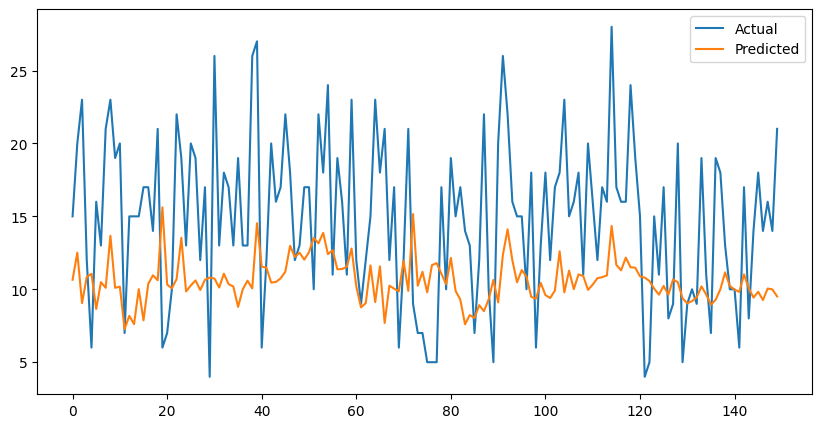

In [29]:
#actual vs predicted plot:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:150], label='Actual')
plt.plot(rf_pred[:150], label='Predicted')
plt.legend()
plt.show()

In [30]:
#checking feature importance: 
importance = pd.DataFrame({"feature": x_train.columns,
"importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print(importance)

                    feature  importance
0                     month    0.636817
16          rolling_mean_30    0.062565
8            promotion_flag    0.037625
5           inventory_level    0.032811
17            rolling_std_7    0.031966
15           rolling_mean_7    0.027019
14                   lag_30    0.023026
13                    lag_7    0.022107
12                    lag_1    0.022043
6             reorder_point    0.019780
3               sku_encoded    0.017406
11                unit_cost    0.016538
10               unit_price    0.016448
1               day_of_week    0.012653
7   supplier_lead_time_days    0.012266
4         warehouse_encoded    0.007306
2                is_weekend    0.001624
9             stockout_flag    0.000000


In [31]:
#prediction dist
print(y_test.describe())
print(pd.Series(rf_pred).describe())

count    15000.000000
mean        15.335333
std          5.908503
min          0.000000
25%         11.000000
50%         15.000000
75%         19.000000
max         44.000000
Name: units_sold, dtype: float64
count    15000.000000
mean        10.815925
std          1.689847
min          5.520000
25%          9.730000
50%         10.560000
75%         11.610000
max         21.370000
dtype: float64


using another model

In [32]:
import xgboost
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(x_train, y_train)
xgb_pred = xgb.predict(x_test)

In [33]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = mean_squared_error(y_test, xgb_pred)**0.5
xgb_r2 = r2_score(y_test, xgb_pred)

print(f"XGBoost MAE  : {xgb_mae:.2f}")
print(f"XGBoost RMSE : {xgb_rmse:.2f}")
print(f"XGBoost R²   : {xgb_r2:.4f}")

XGBoost MAE  : 5.58
XGBoost RMSE : 6.90
XGBoost R²   : -0.3645


In [34]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Random Forest", "XGBoost"],
    "MAE": [mae, rf_mae, xgb_mae],
    "RMSE": [rmse, rf_rmse, xgb_rmse]
})

comparison.sort_values("MAE")

,Model,MAE,RMSE
2,XGBoost,5.575739,6.901712
1,Random Forest,5.809765,7.177282
0,Baseline,5.932133,7.495367


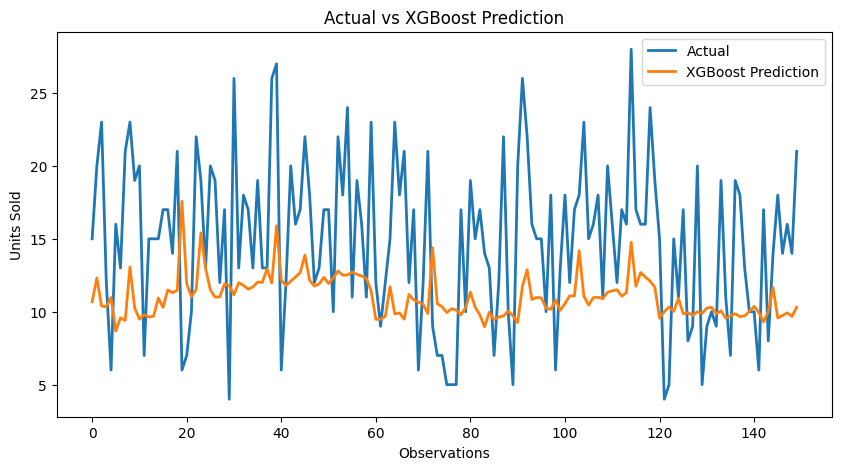

In [35]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:150], label="Actual", linewidth=2)
plt.plot(xgb_pred[:150], label="XGBoost Prediction", linewidth=2)

plt.title("Actual vs XGBoost Prediction")
plt.xlabel("Observations")
plt.ylabel("Units Sold")
plt.legend()

plt.show()

In [36]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

lr_pred = lr.predict(x_test)

print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE:", mean_squared_error(y_test, lr_pred)**0.5)
print("R2 :", r2_score(y_test, lr_pred))

MAE : 6.341614289134995
RMSE: 7.675427174836554
R2 : -0.6876371907463465


In [37]:
from lightgbm import LGBMRegressor

lgb = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgb.fit(x_train, y_train)

lgb_pred = lgb.predict(x_test)
print("MAE :", mean_absolute_error(y_test, lgb_pred))
print("RMSE:", mean_squared_error(y_test, lgb_pred)**0.5)
print("R2 :", r2_score(y_test, lgb_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002163 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1866
[LightGBM] [Info] Number of data points in the train set: 68750, number of used features: 17
[LightGBM] [Info] Start training from score 20.792596
MAE : 5.510666264136909
RMSE: 6.832371405388891
R2 : -0.3372632491802561


In [38]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=False,
    random_seed=42
)

cat.fit(x_train, y_train)

cat_pred = cat.predict(x_test)

print("MAE :", mean_absolute_error(y_test, cat_pred))
print("RMSE:", mean_squared_error(y_test, cat_pred)**0.5)
print("R2 :", r2_score(y_test, cat_pred))

MAE : 5.486729185134285
RMSE: 6.806423142259589
R2 : -0.3271251098118164


# Conclusion

The objective of this notebook was to develop a demand forecasting pipeline that can serve as the foundation for inventory optimization.

Historical sales data was transformed into a time-series forecasting dataset by engineering calendar-based features, lag variables, rolling statistics, and relevant business features such as inventory level, lead time, pricing, and promotions. Multiple machine learning models including Random Forest, XGBoost, LightGBM, and CatBoost were evaluated against a naive persistence baseline.

During model development, an important data granularity issue was identified. Forecasting initially performed at the SKU level produced inconsistent results because inventory-related features existed at the warehouse level. Reconstructing the dataset at the Warehouse–SKU–Date level significantly improved model performance and resulted in a substantial reduction in forecasting error.

Among the evaluated models, gradient boosting methods consistently achieved the best performance, with CatBoost producing the lowest MAE, closely followed by XGBoost and LightGBM. The results also demonstrate that careful feature engineering and selecting the correct level of aggregation had a much greater impact on forecasting accuracy than simply changing algorithms.

Although the dataset is synthetic and lacks several real-world demand drivers (such as holidays, weather, competitor pricing, and macroeconomic factors), the developed forecasting pipeline provides reliable demand estimates that will be used in the next stage of the project for inventory optimization, reorder point calculation, safety stock estimation, and automated replenishment recommendations.

In [40]:
forecast_results= test[['date','sku_id','units_sold']].copy()
forecast_results['predicted_demand']= cat_pred
forecast_results.rename(columns={'units_sold':'actual_demand'},inplace=True)

In [41]:
forecast_results.to_csv("forecast_results.csv",index=False)

In [44]:
print(forecast_results.columns)

Index(['date', 'sku_id', 'actual_demand', 'predicted_demand'], dtype='object')
